In [114]:
#import statments
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import norm


In [115]:
#Black - Scholes prices

S0 = 100
K = 100
T = 1
r = 0.03
sd = 0.20

d1 = (np.log(S0/K) + (r + 0.5 * sd**2) * T) / (sd * np.sqrt(T))
d2 = round(d1 - sd*np.sqrt(T),3)

V_BS = S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
print("Black-Scholes price:", V_BS)

Black-Scholes price: 9.413403383853016


In [116]:
def monte_carlo(M):
    Z = np.random.normal(0,1,M)

    ST = S0 * np.exp((r - 0.5 * sd**2) * T + sd * np.sqrt(T) * Z)

    payoff = np.maximum(ST-K,0)
    
    price_est = np.exp(-r * T)*np.mean(payoff)

    sample_sd = np.std(payoff, ddof=1)
    sample_sd_error = np.exp(-r * T)*sample_sd/np.sqrt(M)
    confid_U = price_est + 1.96*sample_sd_error
    confid_L = price_est - 1.96*sample_sd_error
    confid = [float(confid_U), float(confid_L)]
    return price_est, confid


price, confid = monte_carlo(10000)
print(price)
print(confid)

9.446655096791037
[9.723574307786304, 9.16973588579577]


In [122]:
#convergence study
M_list = [10**2, 5*10**2, 10**3, 5*10**3, 10**4, 5*10**4, 10**5,5*10**5]
R = 100
RMSE_list = []
Vm_one = []

all_CI_low = []
all_CI_high = []
all_Vm = []

coverage_list = []

for M in M_list:

    Vm_list = np.array([])

    for x in range(R):

        Vm, con = monte_carlo(M)
        Vm_list= np.append(Vm_list, Vm)


    Vm_one.append(Vm_list[0])

    RMSE = np.sqrt(np.mean((Vm_list-V_BS)**2))
    RMSE_list.append(float(RMSE))
    all_Vm.append(Vm_list)
    
print(RMSE_list)

[1.5579984596512235, 0.6604576475573399, 0.43808806551150814, 0.21735082383513932, 0.130580205432421, 0.06088592599332291, 0.04527243712377831, 0.018788415419716504]


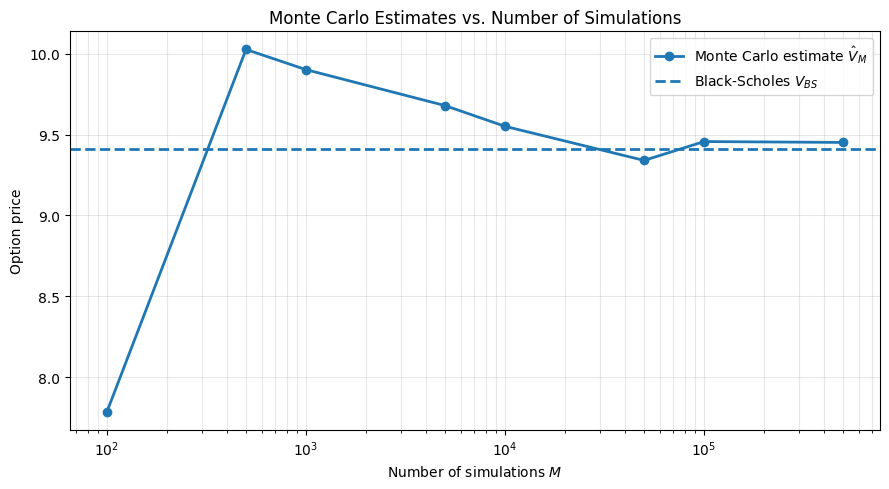

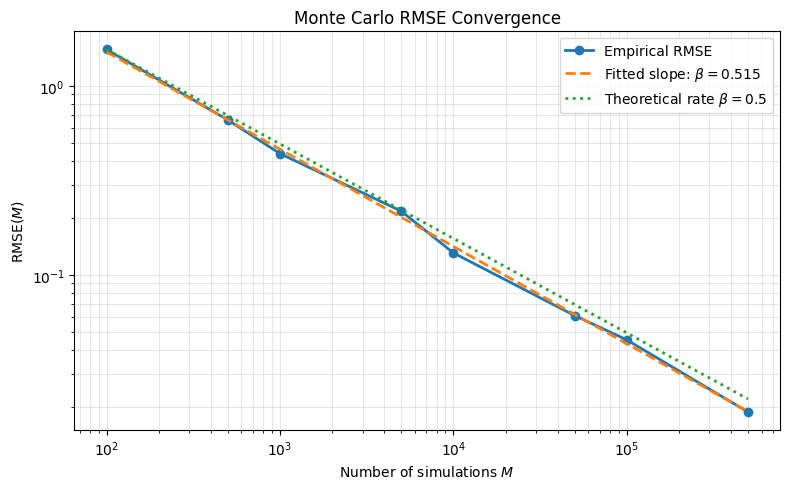

Estimated beta: 0.5146277246914609
Theoretical beta: 0.5


In [126]:
#plots
plt.figure(figsize=(9, 5))

# Representative Monte Carlo estimates
plt.plot(
    M_list,
    Vm_one,
    marker="o",
    linewidth=2,
    markersize=6,
    label=r"Monte Carlo estimate $\hat{V}_M$"
)


plt.axhline(
    y=V_BS,
    linestyle="--",
    linewidth=2,
    label=r"Black-Scholes $V_{BS}$"
)

plt.xscale("log")

plt.xlabel("Number of simulations $M$")
plt.ylabel("Option price")
plt.title("Monte Carlo Estimates vs. Number of Simulations")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()




#plot for rmse against M
# Convert to numpy arrays
M_array = np.array(M_list)
RMSE_array = np.array(RMSE_list)

# Log-transform
log_M = np.log(M_array)
log_RMSE = np.log(RMSE_array)

# Fit: log(RMSE) = a + slope * log(M)
slope, a = np.polyfit(log_M, log_RMSE, 1)

# Since slope = -beta
beta_est = -slope

# Fitted RMSE values
RMSE_fit = np.exp(a) * M_array**(-beta_est)

# Theoretical M^(-1/2) reference line
# Scaled to pass through the first RMSE point
theoretical_line = RMSE_array[0] * (M_array / M_array[0])**(-0.5)

# Plot
plt.figure(figsize=(8, 5))

plt.loglog(
    M_array,
    RMSE_array,
    marker="o",
    linewidth=2,
    markersize=6,
    label="Empirical RMSE"
)

plt.loglog(
    M_array,
    RMSE_fit,
    linestyle="--",
    linewidth=2,
    label=fr"Fitted slope: $\beta={beta_est:.3f}$"
)

plt.loglog(
    M_array,
    theoretical_line,
    linestyle=":",
    linewidth=2,
    label=r"Theoretical rate $\beta=0.5$"
)

plt.xlabel("Number of simulations $M$")
plt.ylabel("RMSE$(M)$")
plt.title("Monte Carlo RMSE Convergence")

plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

print("Estimated beta:", beta_est)
print("Theoretical beta:", 0.5)

